In [1]:
%load_ext autoreload
%autoreload 2
import torch

from torch import nn
from Systems import RevDuff
import numpy as np

from NN import Main_Network, NN
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from Observer import System_z, Observer
import torch.nn.functional as F

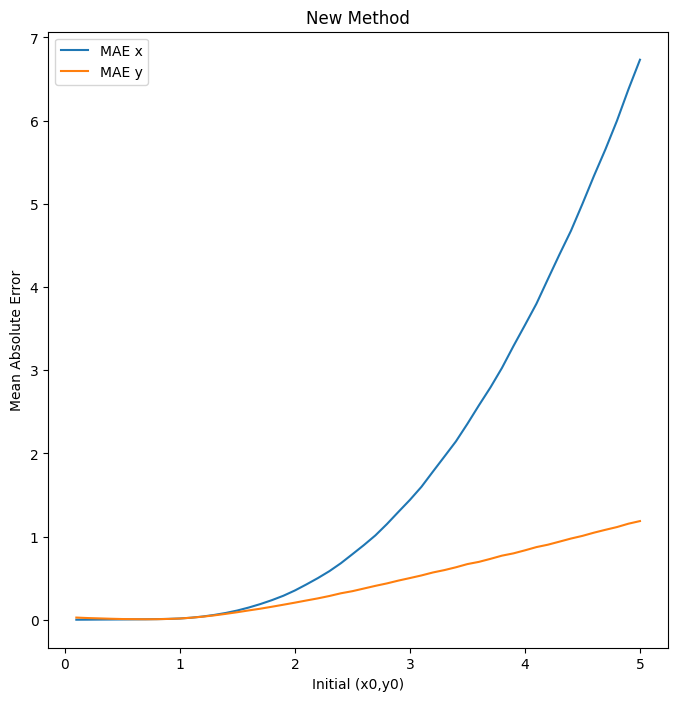

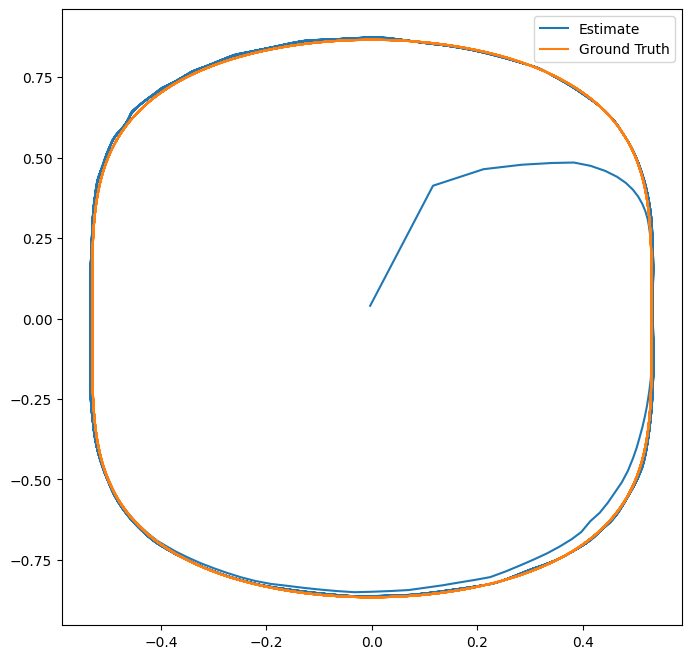

In [2]:
#------------- RevDuff ------------- 
M5_diag = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K5_diag = np.array([[1,1,1,1,1]]).T    # Choose K matrix
revduff = RevDuff(5, add_noise=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 1000
a = 0
b = 50

model_data = torch.load('models/duffing_T_inverse_lr0.001_batch32_epoch15', map_location=torch.device('cpu'))
num_hidden = model_data['config']['num_hidden']
hidden_size = model_data['config']['hidden_size']
x_size = model_data['config']['x_size']
z_size = model_data['config']['z_size']
activation = model_data['config']['activation']
normalizer = model_data['config']['normalizer']
T_inv_net = NN(num_hidden, hidden_size, z_size, x_size, activation, normalizer=normalizer).to(device)
T_inv_net.load_state_dict(model_data['model'])
T_inv_net.eval()

observer2 = Observer(revduff, M5_diag, K5_diag, T_inv_net, a, b, N, init_z_zero=True)

initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_new = []
MAE_y_list_new = []

for ic in initial_conds:
    ic = np.array([[ic, ic]])
    #sys_dim5.toggle_noise()
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    MAE_x = np.mean(error[0][:,0])
    MAE_y = np.mean(error[0][:,1])
    MAE_x_list_new.append(MAE_x)
    MAE_y_list_new.append(MAE_y)

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(initial_conds, MAE_x_list_new, label = 'MAE x')
plt.plot(initial_conds, MAE_y_list_new, label = 'MAE y')
plt.legend()
plt.title('New Method')
plt.xlabel('Initial (x0,y0)')
plt.ylabel('Mean Absolute Error')
plt.show()

ic = np.array([[0.5, 0.5]])
#sys_dim5.toggle_noise()
x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
fig = plt.figure(figsize = (8,8), facecolor='w')
p1, = plt.plot(x_hat[:,0], x_hat[:,1])
p2, = plt.plot(x[:,0], x[:,1])
plt.legend([p1, p2], ['Estimate', 'Ground Truth'])
plt.show()

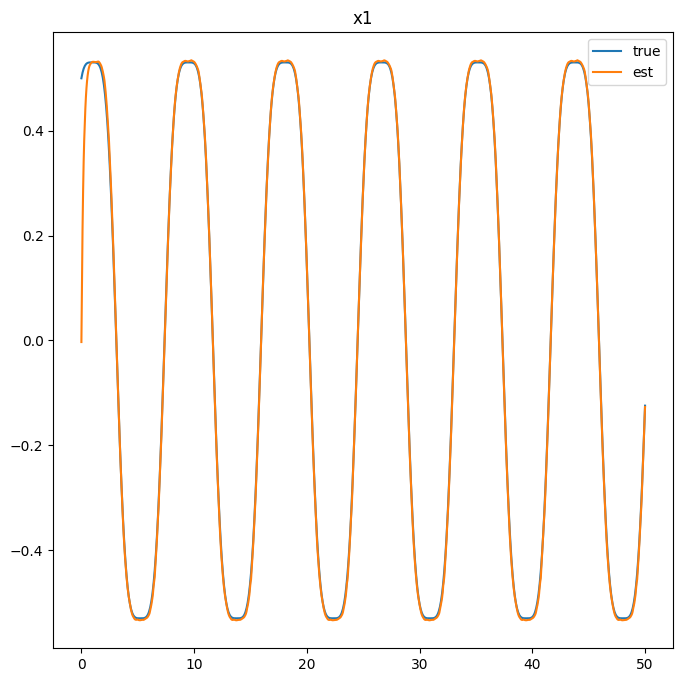

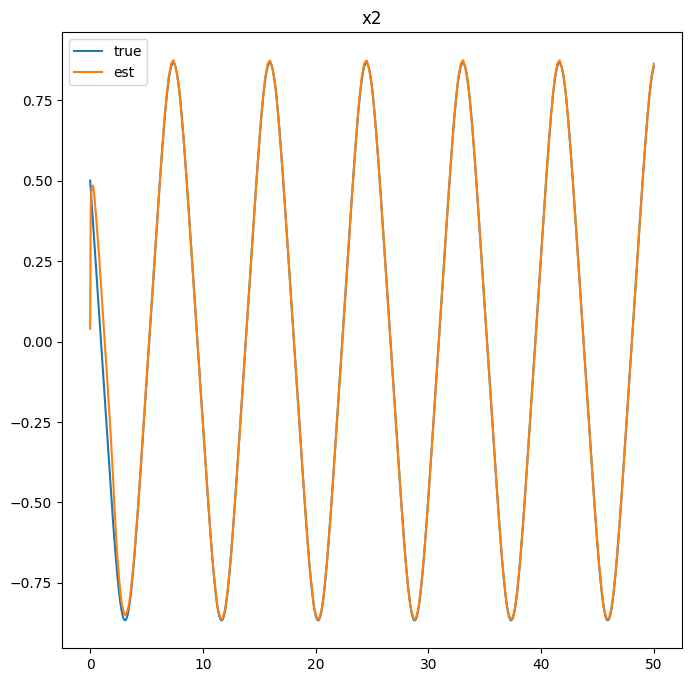

In [3]:
ic = np.array([[0.5, 0.5]])

x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,0], label = 'true')
plt.plot(t, x_hat[:,0], label = 'est')
plt.title('x1')
plt.legend()
plt.show()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,1], label = 'true')
plt.plot(t, x_hat[:,1], label = 'est')
plt.title('x2')
plt.legend()
plt.show()

In [5]:
def eval_errors(xs, xs_predict):
    errs = np.sqrt(((xs - xs_predict) ** 2).mean(-1).mean(0))
    tot = errs.mean()
    return tot

num_ic = 1000
init_conds = np.random.uniform(-1,1,[num_ic,1,2])

x_true = np.zeros([num_ic, N+1, revduff.x_size])
x_pred = np.zeros([num_ic, N+1, revduff.x_size])

for idx, ic in enumerate(init_conds):
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    x_true[idx, :,:] = x
    x_pred[idx, :,:] = x_hat

x_true = x_true[:,50:,:]
x_pred = x_pred[:,50:,:]


print(eval_errors(x_true, x_pred))

0.00868038437397531


In [3]:
from Observer_old import Observer as Observer_old
#------------- RevDuff Old------------- 
M5_diag = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K5_diag = np.array([[1,1,1,1,1]]).T    # Choose K matrix
A = np.array([-6.5549,  4.6082, -5.2057, 3.3942, 6.0211,
                -10.9772, -2.3362, -3.7164, -3.9566, -3.7166,
                -1.9393, -0.2797, -2.7983, -0.8606, -4.8050,
                -10.5100, -1.0820, -2.6448, -2.1144, -7.0080,
                -10.1003, -0.5111, 1.0275, 3.1996, -0.3463]).reshape(5,5)

B = np.ones([5,1])
sys_dim5 = RevDuff(5, add_noise=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 1000
a = 0
b = 50
path = '/Users/johncao/Documents/Programming/kth_research/ACC_KKL_Observer/supervised_PINN'
model = torch.load(path, map_location=torch.device('cpu'))

observer2 = Observer_old(sys_dim5, A, B, model, a, b, N, init_z_zero=True)

#initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_old = []
MAE_y_list_old = []

# for ic in initial_conds:
#     ic = np.array([[ic, ic]])
#     #sys_dim5.toggle_noise()
#     x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
#     MAE_x = np.mean(error[0][:,0])
#     MAE_y = np.mean(error[0][:,1])
#     MAE_x_list_old.append(MAE_x)
#     MAE_y_list_old.append(MAE_y)

# fig = plt.figure(figsize = (8,8), facecolor='w')
# plt.plot(initial_conds, MAE_x_list_old, label = 'MAE x')
# plt.plot(initial_conds, MAE_y_list_old, label = 'MAE y')
# plt.legend()
# plt.title('Old Method')
# plt.xlabel('Initial (x0,y0)')
# plt.ylabel('Mean Absolute Error')
# plt.show()


ic = np.array([[0.5, 0.1]])
#sys_dim5.toggle_noise()
x, x_hat, t, error = observer2.simulate(ic, add_noise = False)

fig = plt.figure(figsize = (8,8), facecolor='w')
p1, = plt.plot(x_hat[:,0], x_hat[:,1])
p2, = plt.plot(x[:,0], x[:,1])
plt.legend([p1, p2], ['Estimate', 'Ground Truth'])
plt.show()

TypeError: System.__init__() missing 5 required positional arguments: 'add_noise', 'noise_process_mean', 'noise_process_std', 'noise_measurement_mean', and 'noise_measurement_std'

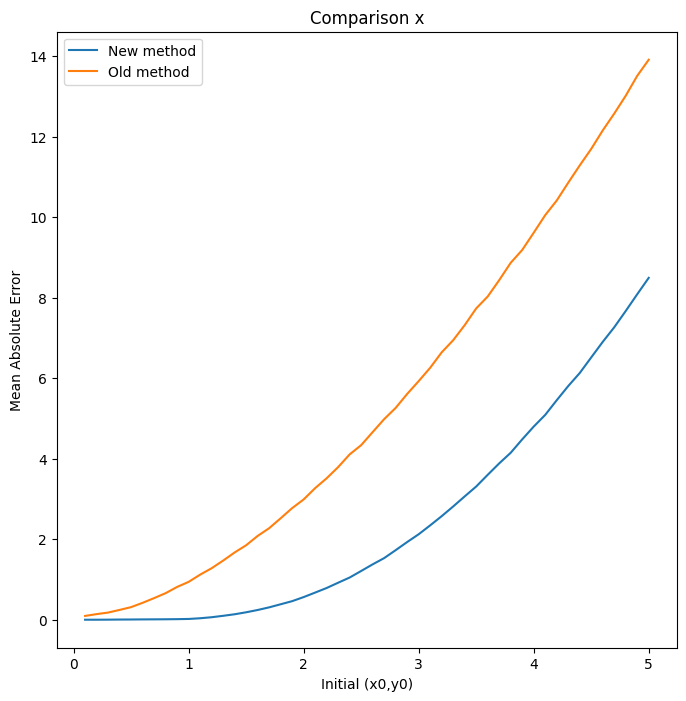

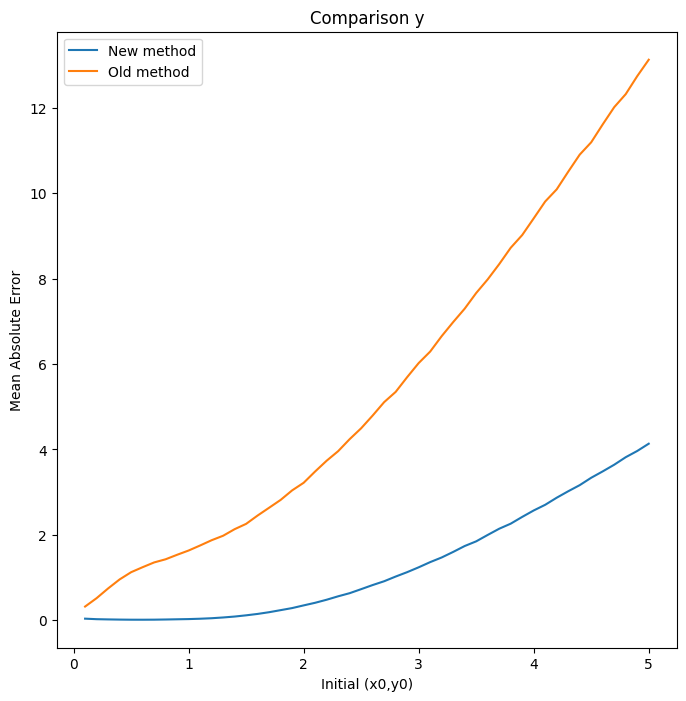

In [14]:
# Plot MAE comparison of new and old method

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(initial_conds, MAE_x_list_new, label = 'New method')
plt.plot(initial_conds, MAE_x_list_old, label = 'Old method')
plt.legend()
plt.title('Comparison x')
plt.xlabel('Initial (x0,y0)')
plt.ylabel('Mean Absolute Error')
plt.show()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(initial_conds, MAE_y_list_new, label = 'New method')
plt.plot(initial_conds, MAE_y_list_old, label = 'Old method')
plt.legend()
plt.title('Comparison y')
plt.xlabel('Initial (x0,y0)')
plt.ylabel('Mean Absolute Error')
plt.show()
